# Poisson equation in a rectangle

$$
\mathbb{S}
\begin{cases}
\Omega = [0, L_x] \times [0, L_y] \\
u_{\text{D}}(x,y=0)=0 \\
u_{\text{D}}(x,y=L_y)=1 \\
u_{\text{D}}(x=0,y)=y/L_y \\
u_{\text{N}}(x=L_x,y)=y(L_y - y) \\
f(x, y) = x + y^2  
\end{cases}
$$

In [1]:
from dolfinx.fem import FunctionSpace
from lucifex.mesh import rectangle_mesh, mesh_boundary
from lucifex.fem import Function as Function
from lucifex.solver import bvp, BoundaryConditions
from lucifex.viz import plot_colormap, plot_line, save_figure
from lucifex.fe2py import cross_section
from lucifex.pde.poisson import poisson

Lx = 2.0
Ly = 1.0
mesh = rectangle_mesh(Lx, Ly, 20, 10)
boundary = mesh_boundary(
    mesh, 
    {
        "left": lambda x: x[0],
        "right": lambda x: x[0] - Lx,
        "lower": lambda x: x[1],
        "upper": lambda x: x[1] - Ly,
    },
)

fs = FunctionSpace(mesh, ('P', 1))
f = Function(fs, lambda x: x[0] + x[1] **2, name='f')

bcs = BoundaryConditions(
    ("dirichlet", boundary['lower'], 0.0),
    ("dirichlet", boundary['upper'], 1.0),  
    ("dirichlet", boundary['left'], lambda x: x[1] / Ly), 
    ("neumann", boundary["right"], lambda x: x[1] * (Ly - x[1])),
)
u = Function(fs, name='u')
u_solver = bvp(poisson, bcs)(u, f)
u_solver.solve()

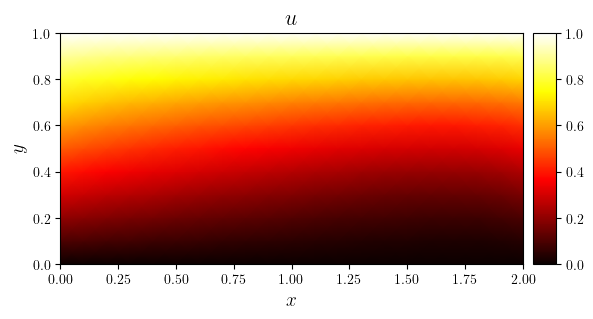

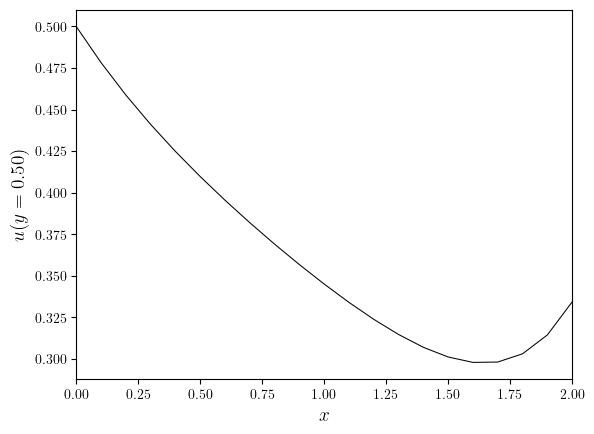

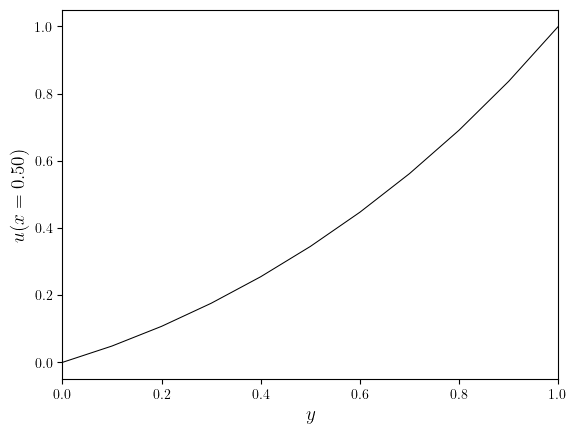

In [2]:
fig, ax = plot_colormap(u, title=f'${u.name}$')
save_figure('u(x,y)', thumbnail=True)(fig)

x_axis, ux, y_value = cross_section(u, 'y', 0.5)
plot_line((x_axis, ux), x_label='$x$', y_label=f'${u.name}(y={y_value:.2f})$')
save_figure(f'u(x,y={y_value:.2f})')(fig)

y_axis, uy, x_value = cross_section(u, 'x', 0.5)
plot_line((y_axis, uy), x_label='$y$', y_label=f'${u.name}(x={y_value:.2f})$')
save_figure(f'u(x={x_value:.2f},y)')(fig)